In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from src.utils import get_dataset, get_diffusion_schedule_nickname, get_diffusion_weights, get_n_qubits_from_data, set_device, get_path
from src.QDDPM_torch_angel import QDDPMDiffuser
from tqdm import tqdm
import pytorch_optimizer
from functools import partial
from livelossplot import PlotLosses
from opt_einsum import contract
import qutip as qt
from qutip import Bloch
from src.QDDPM_torch_angel import WassDistance
from sklearn.model_selection import train_test_split

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

def ndim_cluster0Gen(n_data, n_qubits, epsilon, rng=None):
    states0 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states0[:, 0] = 1.
    states1 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states1[:, 1] = 1.

    re_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    im_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    c = re_c + 1j*im_c
    c = c[:, np.newaxis]
    states = states0 + epsilon*c*states1
    states /= np.linalg.norm(states, axis=1, keepdims=True)
    
    return states

def gen_data(config, diffuser: QDDPMDiffuser, diffusion_weights, t, rng):
    device = config['device']
    size = config['dataset']['maxsize']
    size = size if size is not None else 60000
    name = config['dataset']["name"]
    parts = name.split('_')
    n_qubits = int(parts[1])
    n_features = 2**n_qubits
    initialqstates = ndim_cluster0Gen(size, int(n_qubits), epsilon=0.08, rng=rng)

    # Now diffuse just one timestep.
    states_diffused = torch.zeros((t+1, size, n_features), dtype=torch.complex64, device=device)
    states_diffused[0] = torch.from_numpy(initialqstates).to(device)
    for tt in (range(1, t+1)):
        # states[t] = model.set_diffusionData_t(t, states[0], diffusion_weights[:t], seed=t)
        states_diffused[tt] = diffuser.set_diffusionData_t_single_step(tt, states_diffused[tt-1], diffusion_weights[:tt], seed=tt)
        states_diffused[tt] = states_diffused[tt] / torch.norm(states_diffused[tt], dim=1, keepdim=True) # Avoid numerical errorsdir, filename = get_path(self.config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
    X, y = states_diffused[t].cpu(), states_diffused[t-1].cpu() # The two steps involved in the current timestep t.
    return X, y    

config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './results_MLP',
        'name': 'CLUSTER0_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 1000
    },
    'model': {
        'n_timesteps': 20,
        'diffusion_schedule': {
            'name': 'linear',
            'slope': 6,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}

n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits
diffusion_schedule_nickname = get_diffusion_schedule_nickname(config)
n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
get_path_partial = partial(get_path, config, modeltype='MLP', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)

I0000 00:00:1776330858.332465 2311666 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776330859.548735 2311666 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
/home/angel/miniconda3/envs/dffs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as n

Using device: cpu


In [3]:
class MLP(torch.nn.Module):
    def __init__(self, input_feats, n_hidden_layers, output_feats):
        super().__init__()
        input_dim = 2*input_feats
        output_dim = 2*output_feats
        hidden_dim = 8*input_dim
        layers = []
        for _ in range(n_hidden_layers):
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.ReLU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, output_dim))
        self.mlp = torch.nn.Sequential(*layers)

    def forward(self, x): # x.shape = (batch_size, n_features (complex))
        batch_size = x.shape[0]
        x = torch.view_as_real(x) # (batch_size, n_features, 2)
        x = x.view(batch_size, -1)
        x_output = self.mlp(x)
        x_output = x_output.view(batch_size, -1, 2)
        x_output = torch.view_as_complex(x_output)
        norm = torch.linalg.norm(x_output, dim=1, keepdim=True)
        x_output = x_output / norm
        return x_output
    
def quantum_mean_infidelity(pred, true):
    # pred and true are [n_data, n_features] complex tensors
    inner_product = torch.linalg.vecdot(true, pred, dim=-1) # [n_data]
    fidelity = inner_product.abs().pow(2)
    infidelity = 1 - fidelity
    return infidelity.mean()

def mse(pred, true):
    pred_float = torch.view_as_real(pred)
    true_float = torch.view_as_real(true)
    return torch.nn.functional.mse_loss(pred_float, true_float)

def simple_regularization_term(model, lambd=0.1):
    return lambd * sum(p.pow(2).sum() for p in model.parameters())

def eval(model, x):
    model.eval()
    y = model(x)
    return y

## Trainings

Timestep 20

In [4]:
# Savedir
savedir = Path('results_mlp_pocoapoco/models')

from livelossplot.outputs import MatplotlibPlot
def custom_after_subplot(ax: plt.Axes, group_name: str, x_label: str):
    ax.set_title(group_name)
    ax.set_xlabel(x_label)
    ax.legend(loc='center right')
    ax.set_yscale('log')
outputs = [MatplotlibPlot(after_subplot=custom_after_subplot)]

# Declaramos el modelo
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)#.to(torch.float64)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
print(model)

2404
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)


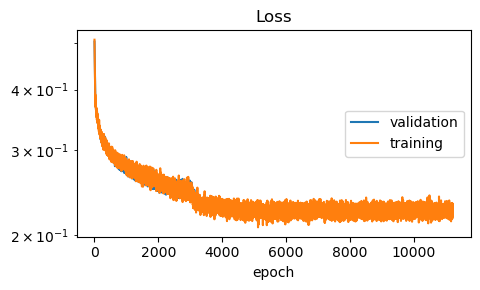

Epoch 11270/2000 Loss: 2.120e-01, LR: 1.2e-08, Last_save: 5120: : 11269it [10:08, 19.49it/s]

KeyboardInterrupt: 

In [ ]:
# Training loop
loss_fn = quantum_mean_infidelity
lr = 4e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
step_size = 500
n_epochs = 4*step_size
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=200, cooldown=0)
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 20 # 20 --> 19
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)

seed = config["seed"]
rng = np.random.default_rng(seed)
X_val, y_val = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

logs = {}
epochs = []
val_epochs = []
best_loss = float('inf')
last_save_epoch = 0
avg_val_loss_epoch = float('inf')
goal = 0.005
pbar = tqdm()
epoch = 0
while avg_val_loss_epoch > goal or lr_scheduler.get_last_lr()[0] < 2e-8:
    model.train()
    train_loss_epoch = 0

    # Generate new data at each epoch (reproducible)
    X, y = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
    train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=False)


    for batch in train_dataloader:
        X, y = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)# + simple_regularization_term(model, lambd=1e-1)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)

    model.eval()
    with torch.no_grad():
        val_loss_epoch = 0
        for batch in val_dataloader:
            X, y = batch
            # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
            X, y = X.to(device), y.to(device)
            x = model(X)
            loss = loss_fn(x, y)
            loss_value = loss
            val_loss_epoch += loss_value
        avg_val_loss_epoch = val_loss_epoch / len(val_dataloader)
        logs['val_loss'] = avg_val_loss_epoch
        val_epochs.append(epoch)

    logs['loss'] = avg_train_loss_epoch
    epochs.append(epoch)
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}, Loss: {loss_value:.3e}/{goal:.1e}, LR: {lr_scheduler.get_last_lr()[0]:.1e}, Last_save: {last_save_epoch}')
    lr_scheduler.step(avg_val_loss_epoch)

    if avg_val_loss_epoch < best_loss:
        best_loss = avg_val_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'train_loss_hist': logs['loss'],
                'val_loss_hist': logs['val_loss'],
                'epochs_hist': epochs,
                'val_epochs_hist': val_epochs
                }, path)
    if epoch %49 == 0:
            liveloss.send()
    epoch += 1
    pbar.update(1)
pbar.close()
print(f'Loss goal {goal} reached!')

Wass distance: 2.547e-02 --> 2.691e-02
Difference: -1.448e-03
Total Trainable Parameters: 2,404


/tmp/ipykernel_2311666/2929787357.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


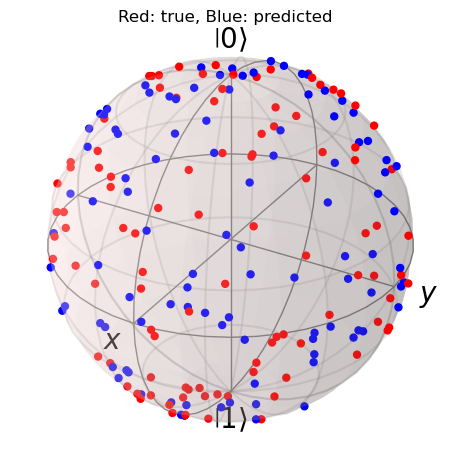

In [9]:
# Print the evolution of the wass distance
X, y = next(iter(val_dataloader))
x = eval(model, X)
wass_true = WassDistance(X, y)
wass_pred = WassDistance(X, x)
print(f'Wass distance: {wass_true:.3e} --> {wass_pred:.3e}')
print(f'Difference: {wass_true - wass_pred:.3e}')

# Print some stats of the model
n_params = sum(p.numel() for p in model.parameters())
print(f'Total Trainable Parameters: {n_params:,}')

# Bloch visualize on the forward noise process
filename = f'bestmodel_{TIMESTEP}.pt'
input_feats, n_hidden_layers, output_feats = 2**n_qubits, 3, 2**n_qubits
checkpoint = torch.load(savedir/filename)
model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
model_finetuned.load_state_dict(checkpoint['model_state_dict'])

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
b = Bloch(fig=fig, axes=ax)

# y = states_diffused[TIMESTEP-1].numpy()
y = y.detach().cpu().numpy()
red_points = bloch_xyz(y) # True

# X = states_diffused[TIMESTEP]
# x = eval(model_finetuned, X)
x = x.detach().cpu().numpy()
blue_points = bloch_xyz(x)

all_points = [np.concatenate((red_points[i], blue_points[i])) for i in range(3)]
b.add_points(all_points)
b.point_color = ['r']*red_points[0].shape[0] + ['b']*blue_points[0].shape[0]
b.point_style = 'm'

b.render()
ax.set_title(f'Red: true, Blue: predicted')
plt.tight_layout()

# Timestep 19

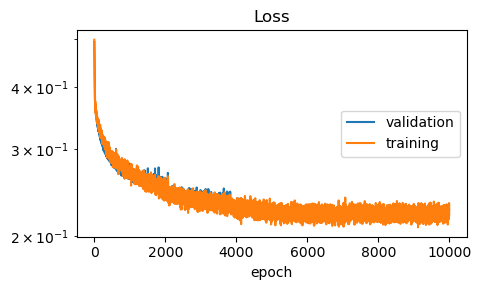

KeyboardInterrupt: 

In [ ]:
# Training loop
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)#.to(torch.float64)
loss_fn = quantum_mean_infidelity
lr = 4e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
step_size = 500
n_epochs = 4*step_size
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=200, cooldown=0)
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 19
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)

seed = config["seed"]
rng = np.random.default_rng(seed)
X_val, y_val = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

logs = {}
epochs = []
val_epochs = []
best_loss = float('inf')
last_save_epoch = 0
avg_val_loss_epoch = float('inf')
goal = 0.005
pbar = tqdm()
epoch = 0
while avg_val_loss_epoch > goal and lr_scheduler.get_last_lr()[0] < 5e-8:
    model.train()
    train_loss_epoch = 0

    # Generate new data at each epoch (reproducible)
    X, y = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
    train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=False)


    for batch in train_dataloader:
        X, y = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)# + simple_regularization_term(model, lambd=1e-1)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)

    model.eval()
    with torch.no_grad():
        val_loss_epoch = 0
        for batch in val_dataloader:
            X, y = batch
            # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
            X, y = X.to(device), y.to(device)
            x = model(X)
            loss = loss_fn(x, y)
            loss_value = loss
            val_loss_epoch += loss_value
        avg_val_loss_epoch = val_loss_epoch / len(val_dataloader)
        logs['val_loss'] = avg_val_loss_epoch
        val_epochs.append(epoch)

    logs['loss'] = avg_train_loss_epoch
    epochs.append(epoch)
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}, Loss: {loss_value:.3e}/{goal:.1e}, LR: {lr_scheduler.get_last_lr()[0]:.1e}, Last_save: {last_save_epoch}')
    lr_scheduler.step(avg_val_loss_epoch)

    if avg_val_loss_epoch < best_loss:
        best_loss = avg_val_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'train_loss_hist': logs['loss'],
                'val_loss_hist': logs['val_loss'],
                'epochs_hist': epochs,
                'val_epochs_hist': val_epochs
                }, path)
    if epoch %49 == 0:
            liveloss.send()
    epoch += 1
    pbar.update(1)
pbar.close()
print(f'Loss goal {goal} reached!')

Wass distance: 2.206e-02 --> 2.450e-02
Difference: -2.446e-03
Total Trainable Parameters: 2,404


/tmp/ipykernel_2311666/2929787357.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


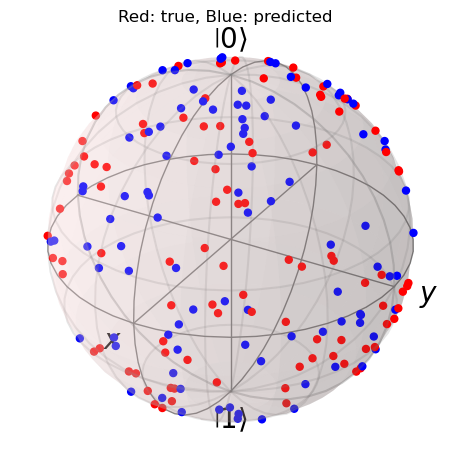

In [13]:
# Print the evolution of the wass distance
X, y = next(iter(val_dataloader))
x = eval(model, X)
wass_true = WassDistance(X, y)
wass_pred = WassDistance(X, x)
print(f'Wass distance: {wass_true:.3e} --> {wass_pred:.3e}')
print(f'Difference: {wass_true - wass_pred:.3e}')

# Print some stats of the model
n_params = sum(p.numel() for p in model.parameters())
print(f'Total Trainable Parameters: {n_params:,}')

# Bloch visualize on the forward noise process
filename = f'bestmodel_{TIMESTEP}.pt'
input_feats, n_hidden_layers, output_feats = 2**n_qubits, 3, 2**n_qubits
checkpoint = torch.load(savedir/filename)
model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
model_finetuned.load_state_dict(checkpoint['model_state_dict'])

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
b = Bloch(fig=fig, axes=ax)

# y = states_diffused[TIMESTEP-1].numpy()
y = y.detach().cpu().numpy()
red_points = bloch_xyz(y) # True

# X = states_diffused[TIMESTEP]
# x = eval(model_finetuned, X)
x = x.detach().cpu().numpy()
blue_points = bloch_xyz(x)

all_points = [np.concatenate((red_points[i], blue_points[i])) for i in range(3)]
b.add_points(all_points)
b.point_color = ['r']*red_points[0].shape[0] + ['b']*blue_points[0].shape[0]
b.point_style = 'm'

b.render()
ax.set_title(f'Red: true, Blue: predicted')
plt.tight_layout()

# Timestep 18

In [75]:
def train(model, TIMESTEP, loss_goal=0.005):
    loss_fn = quantum_mean_infidelity
    lr = 4e-4
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    step_size = 500
    n_epochs = 4*step_size
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=200, cooldown=0)
    batch_size = 100
    liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

    # Diffuse until timestep
    diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
    diffusion_weights = get_diffusion_weights(config, device=device)
    seed = config["seed"]
    rng = np.random.default_rng(seed)
    X_val, y_val = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
    val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    logs = {}
    epochs = []
    val_epochs = []
    best_loss = float('inf')
    last_save_epoch = 0
    avg_val_loss_epoch = float('inf')
    pbar = tqdm()
    epoch = 0
    while avg_val_loss_epoch > loss_goal and (epoch-last_save_epoch) < 500:
        model.train()
        train_loss_epoch = 0

        # Generate new data at each epoch (reproducible)
        X, y = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
        train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=False)


        for batch in train_dataloader:
            X, y = batch
            # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            x = model(X)
            loss = loss_fn(x, y)# + simple_regularization_term(model, lambd=1e-1)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            train_loss_epoch += loss_value
        avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)

        model.eval()
        with torch.no_grad():
            val_loss_epoch = 0
            for batch in val_dataloader:
                X, y = batch
                # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
                X, y = X.to(device), y.to(device)
                x = model(X)
                loss = loss_fn(x, y)
                loss_value = loss
                val_loss_epoch += loss_value
            avg_val_loss_epoch = val_loss_epoch / len(val_dataloader)
            logs['val_loss'] = avg_val_loss_epoch
            val_epochs.append(epoch)

        logs['loss'] = avg_train_loss_epoch
        epochs.append(epoch)
        liveloss.update(logs)
        pbar.set_description(f'Epoch {epoch+1}, Loss: {loss_value:.3e}/{goal:.1e}, LR: {lr_scheduler.get_last_lr()[0]:.1e}, Last_save: {last_save_epoch}')
        lr_scheduler.step(avg_val_loss_epoch)

        if avg_val_loss_epoch < best_loss:
            best_loss = avg_val_loss_epoch
            last_save_epoch = epoch
            filename = f'bestmodel_{TIMESTEP}.pt'
            path = savedir/filename
            savedir.mkdir(parents=True, exist_ok=True)
            torch.save({
                    'model_state_dict': model.state_dict(),
                    'train_loss_hist': logs['loss'],
                    'val_loss_hist': logs['val_loss'],
                    'epochs_hist': epochs,
                    'val_epochs_hist': val_epochs
                    }, path)
        pbar.update(1)
        if epoch %49 == 0:
                liveloss.send()
        epoch += 1
    pbar.close()
    print(f'Training finished.')

# Print the evolution of the wass distance
def show_results(model, TIMESTEP):
    diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
    diffusion_weights = get_diffusion_weights(config, device=device)
    seed = config["seed"]
    rng = np.random.default_rng(seed)
    X_val, y_val = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
    val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    X, y = next(iter(val_dataloader))
    x = eval(model, X)
    wass_true = WassDistance(X, y)
    wass_pred = WassDistance(X, x)
    print(f'Wass distance: {wass_true:.3e} --> {wass_pred:.3e}')
    print(f'Difference: {wass_true - wass_pred:.3e}')

    # Print some stats of the model
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Total Trainable Parameters: {n_params:,}')

    # Bloch visualize on the forward noise process
    filename = f'bestmodel_{TIMESTEP}.pt'
    input_feats, n_hidden_layers, output_feats = 2**n_qubits, 3, 2**n_qubits
    checkpoint = torch.load(savedir/filename)
    model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
    model_finetuned.load_state_dict(checkpoint['model_state_dict'])

    fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
    b = Bloch(fig=fig, axes=ax)

    # y = states_diffused[TIMESTEP-1].numpy()
    y = y.detach().cpu().numpy()
    red_points = bloch_xyz(y) # True

    # X = states_diffused[TIMESTEP]
    # x = eval(model_finetuned, X)
    x = x.detach().cpu().numpy()
    blue_points = bloch_xyz(x)

    all_points = [np.concatenate((red_points[i], blue_points[i])) for i in range(3)]
    b.add_points(all_points)
    b.point_color = ['r']*red_points[0].shape[0] + ['b']*blue_points[0].shape[0]
    b.point_style = 'm'

    b.render()
    ax.set_title(f'Red: true, Blue: predicted')
    plt.tight_layout()

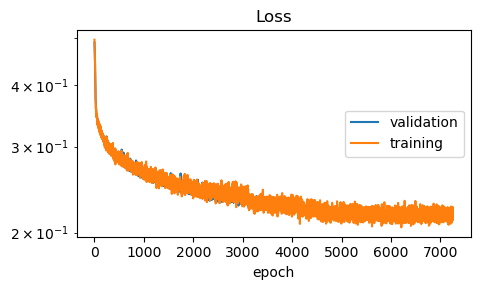

Epoch 7283, Loss: 2.510e-01/5.0e-03, LR: 9.8e-08, Last_save: 5674: : 7283it [06:08, 19.75it/s]

Loss goal 0.005 reached!


In [22]:
# Training loop
TIMESTEP = 18
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)


Wass distance: 2.874e-02 --> 2.198e-02
Difference: 6.768e-03
Total Trainable Parameters: 2,404


/tmp/ipykernel_2311666/1923945628.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


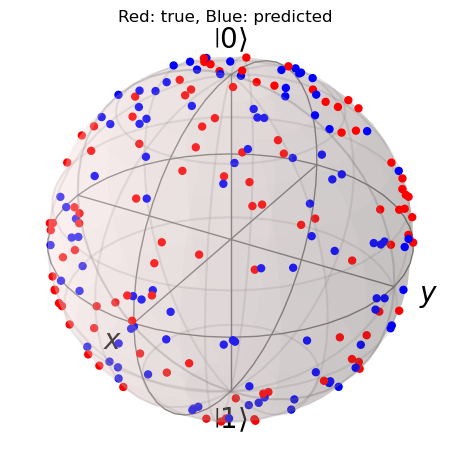

In [26]:
show_results(model, TIMESTEP)

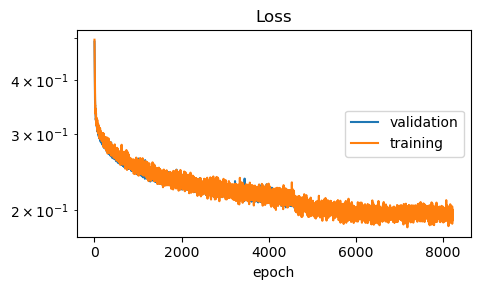

Epoch 8238, Loss: 2.051e-01/5.0e-03, LR: 9.8e-08, Last_save: 6787: : 8238it [06:37, 20.73it/s]

Goal reached!


In [27]:
# Training loop
TIMESTEP = 17
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

Wass distance: 2.566e-02 --> 2.615e-02
Difference: -4.905e-04
Total Trainable Parameters: 2,404


/tmp/ipykernel_2311666/2110384855.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


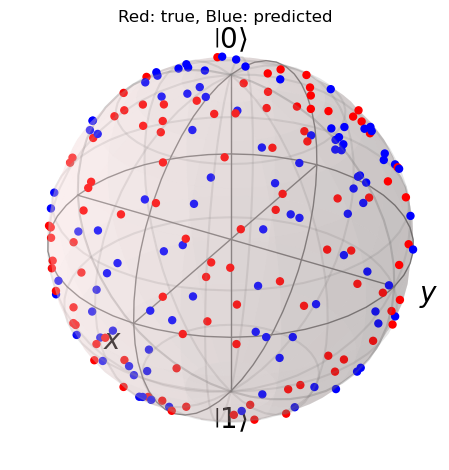

In [30]:
show_results(model, TIMESTEP)

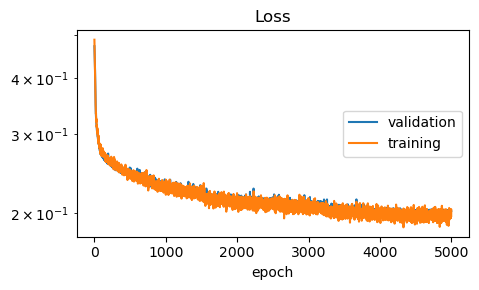

Epoch 5043, Loss: 2.092e-01/5.0e-03, LR: 6.3e-06, Last_save: 4543: : 5043it [03:51, 21.79it/s]

Training finished.


In [42]:
# Training loop
TIMESTEP = 16
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

Wass distance: 2.375e-02 --> 3.586e-02
Difference: -1.211e-02
Total Trainable Parameters: 2,404


/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


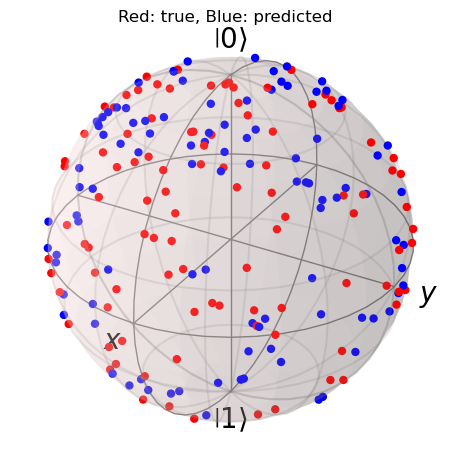

In [43]:
show_results(model, TIMESTEP)

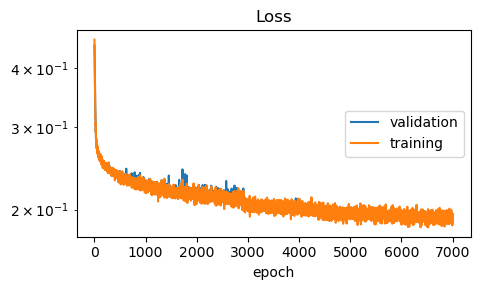

Epoch 7022, Loss: 2.182e-01/5.0e-03, LR: 3.1e-06, Last_save: 6522: : 7022it [04:59, 23.46it/s]

Training finished.


In [44]:
# Training loop
TIMESTEP = 15
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.289e-02 --> 2.977e-02
Difference: -6.882e-03
Total Trainable Parameters: 2,404


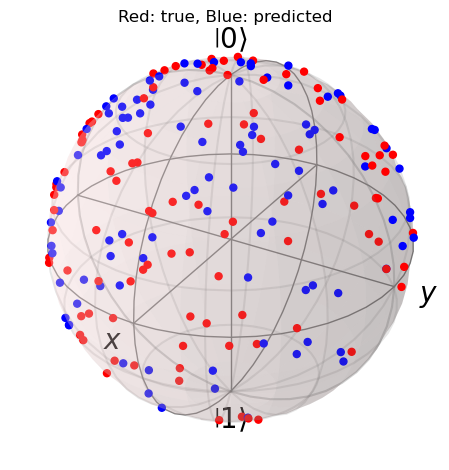

In [45]:
show_results(model, TIMESTEP)

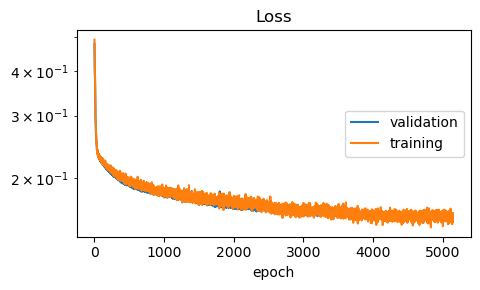

Epoch 5169, Loss: 1.467e-01/5.0e-03, LR: 6.3e-06, Last_save: 4669: : 5169it [03:35, 23.99it/s]

Training finished.


In [46]:
# Training loop
TIMESTEP = 14
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.838e-02 --> 3.483e-02
Difference: -6.450e-03
Total Trainable Parameters: 2,404


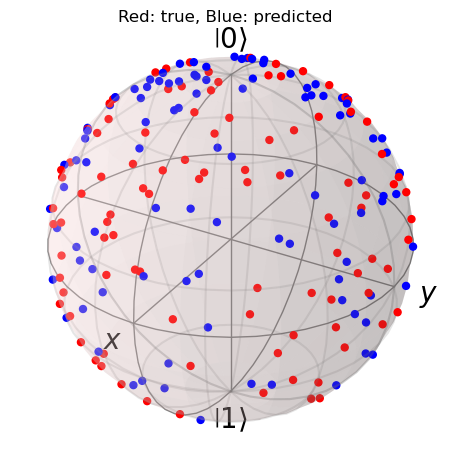

In [47]:
show_results(model, TIMESTEP)

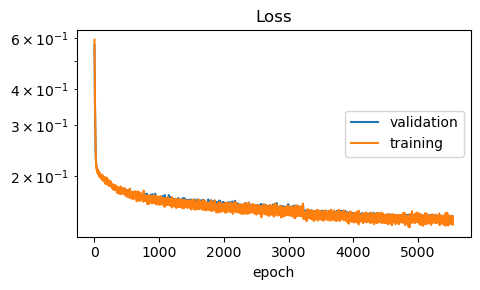

Epoch 5577, Loss: 1.705e-01/5.0e-03, LR: 6.3e-06, Last_save: 5077: : 5577it [03:45, 24.79it/s]

Training finished.


In [48]:
# Training loop
TIMESTEP = 13
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.570e-02 --> 3.915e-02
Difference: -1.345e-02
Total Trainable Parameters: 2,404


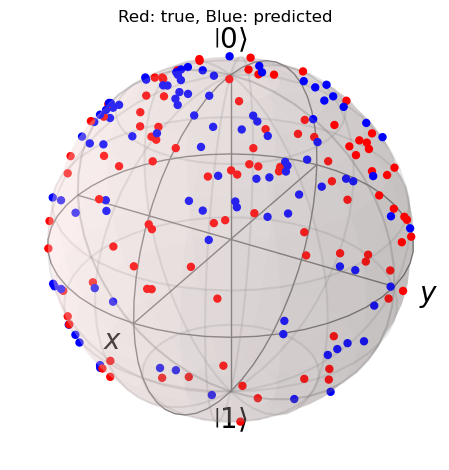

In [49]:
show_results(model, TIMESTEP)

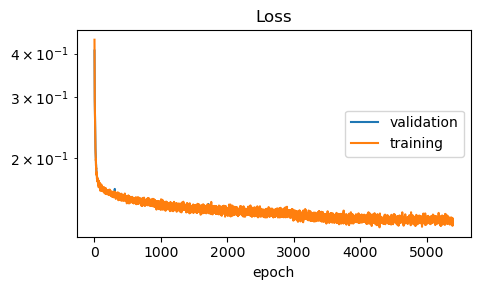

Epoch 5433, Loss: 1.360e-01/5.0e-03, LR: 3.1e-06, Last_save: 4933: : 5433it [03:23, 26.73it/s]

Training finished.


In [50]:
# Training loop
TIMESTEP = 12
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.384e-02 --> 4.261e-02
Difference: -1.877e-02
Total Trainable Parameters: 2,404


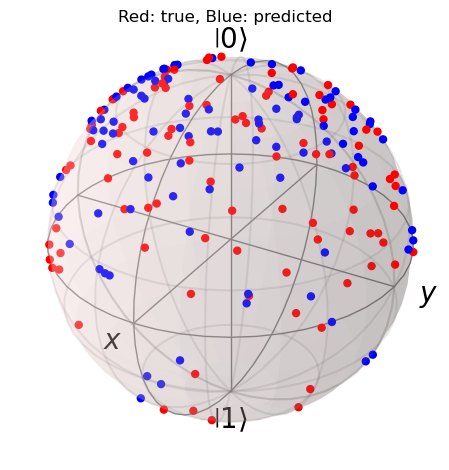

In [51]:
show_results(model, TIMESTEP)

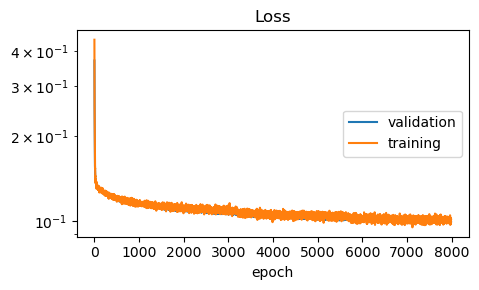

Epoch 8033, Loss: 1.054e-01/5.0e-03, LR: 3.1e-06, Last_save: 7533: : 8033it [05:00, 26.75it/s]

Training finished.


In [52]:
# Training loop
TIMESTEP = 11
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.541e-02 --> 3.575e-02
Difference: -1.033e-02
Total Trainable Parameters: 2,404


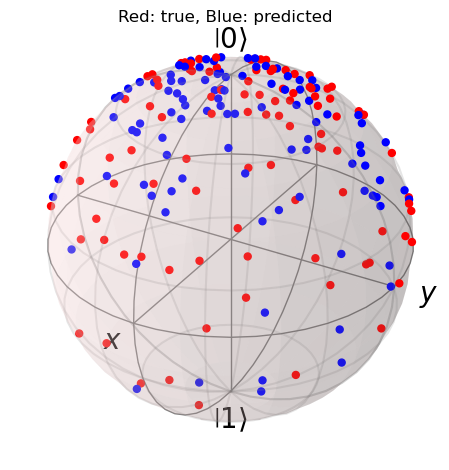

In [53]:
show_results(model, TIMESTEP)

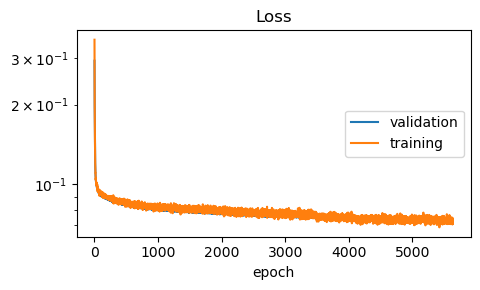

Epoch 5670, Loss: 7.688e-02/5.0e-03, LR: 6.3e-06, Last_save: 5170: : 5670it [03:24, 27.71it/s]

Training finished.


In [54]:
# Training loop
TIMESTEP = 10
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.157e-02 --> 3.993e-02
Difference: -1.836e-02
Total Trainable Parameters: 2,404


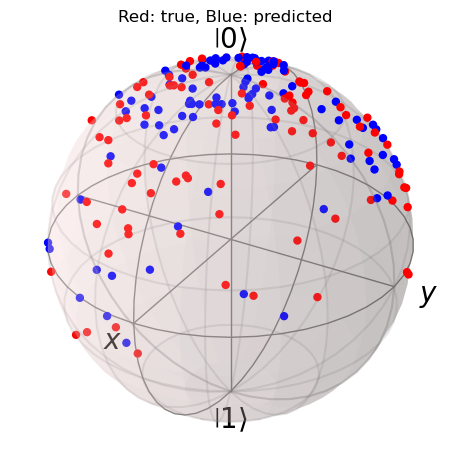

In [55]:
show_results(model, TIMESTEP)

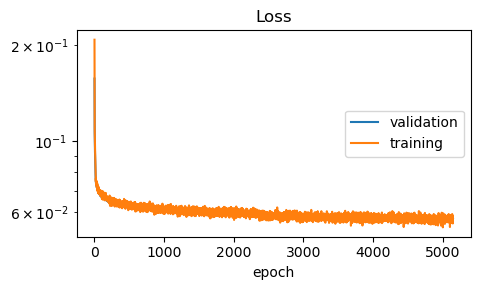

Epoch 5168, Loss: 6.296e-02/5.0e-03, LR: 1.3e-05, Last_save: 4668: : 5168it [03:01, 28.52it/s]

Training finished.


In [56]:
# Training loop
TIMESTEP = 9
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 1.817e-02 --> 2.876e-02
Difference: -1.059e-02
Total Trainable Parameters: 2,404


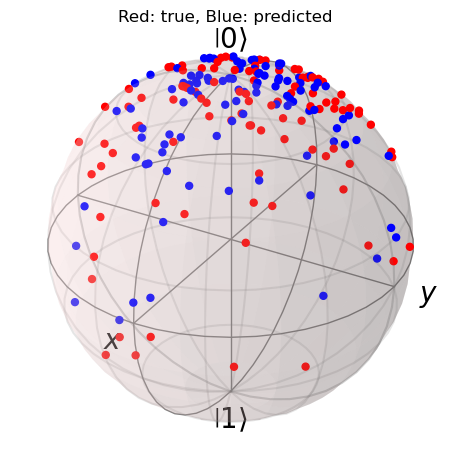

In [57]:
show_results(model, TIMESTEP)

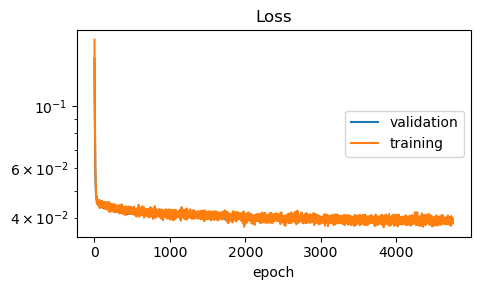

Epoch 4794, Loss: 3.317e-02/5.0e-03, LR: 3.1e-06, Last_save: 4294: : 4794it [02:34, 31.05it/s]

Training finished.


In [58]:
# Training loop
TIMESTEP = 8
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 1.588e-02 --> 2.640e-02
Difference: -1.052e-02
Total Trainable Parameters: 2,404


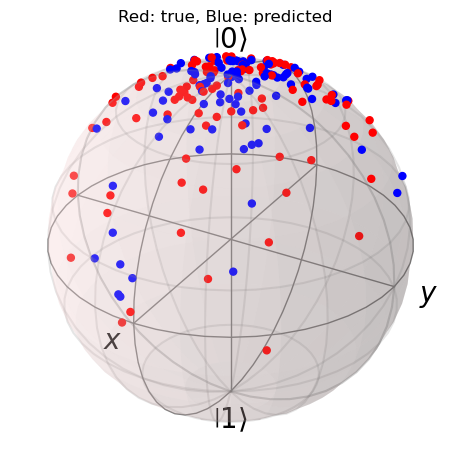

In [59]:
show_results(model, TIMESTEP)

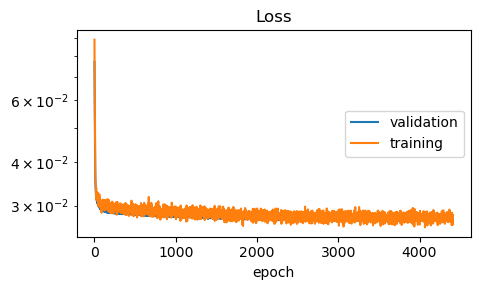

Epoch 4420, Loss: 2.956e-02/5.0e-03, LR: 1.3e-05, Last_save: 3920: : 4420it [02:16, 32.27it/s]

Training finished.


In [60]:
# Training loop
TIMESTEP = 7
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 1.341e-02 --> 2.019e-02
Difference: -6.775e-03
Total Trainable Parameters: 2,404


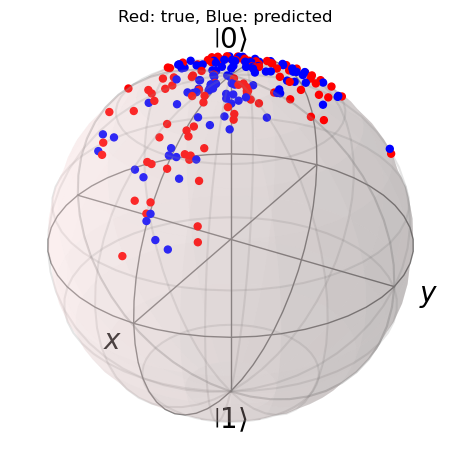

In [61]:
show_results(model, TIMESTEP)

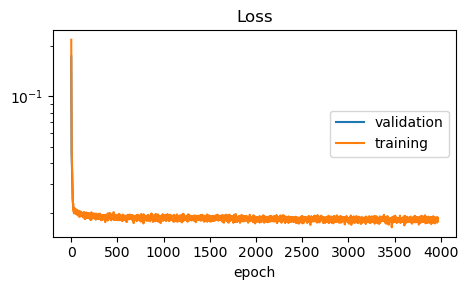

Epoch 4013, Loss: 2.041e-02/5.0e-03, LR: 1.3e-05, Last_save: 3513: : 4013it [02:03, 32.46it/s]

Training finished.


In [62]:
# Training loop
TIMESTEP = 6
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 7.747e-03 --> 1.416e-02
Difference: -6.412e-03
Total Trainable Parameters: 2,404


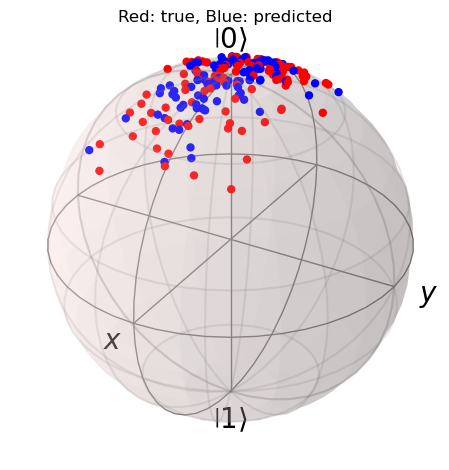

In [63]:
show_results(model, TIMESTEP)

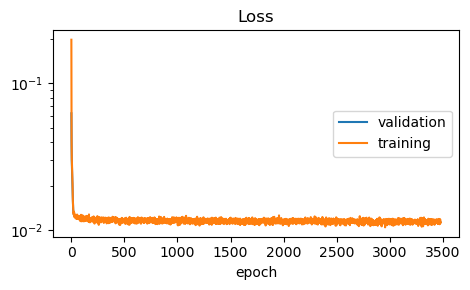

Epoch 3493, Loss: 1.120e-02/5.0e-03, LR: 5.0e-05, Last_save: 2993: : 3493it [01:35, 36.46it/s]

Training finished.


In [64]:
# Training loop
TIMESTEP = 5
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP)

/tmp/ipykernel_2311666/2758297217.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 5.701e-03 --> 9.312e-03
Difference: -3.610e-03
Total Trainable Parameters: 2,404


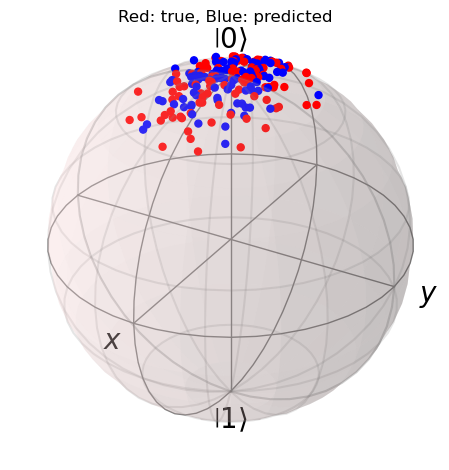

In [65]:
show_results(model, TIMESTEP)

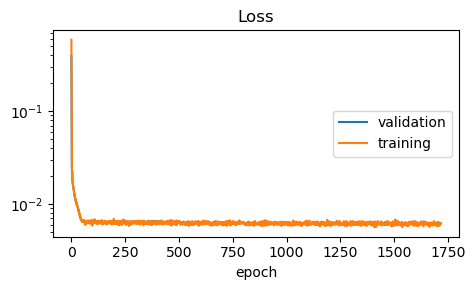

Epoch 1755, Loss: 5.240e-03/5.0e-03, LR: 5.0e-05, Last_save: 1255: : 1755it [00:51, 34.23it/s]

Training finished.


In [77]:
# Training loop
TIMESTEP = 4
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP, loss_goal=1e-4)

/tmp/ipykernel_2311666/782184491.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 1.750e-03 --> 5.393e-03
Difference: -3.643e-03
Total Trainable Parameters: 2,404


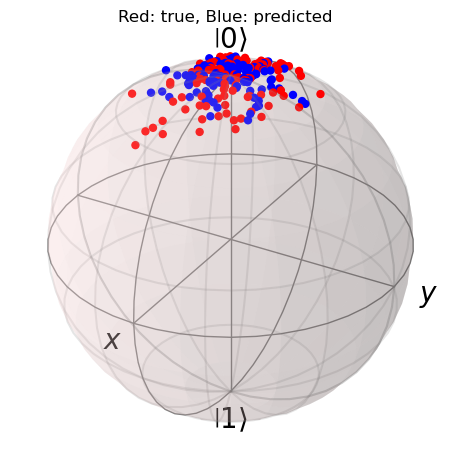

In [78]:
show_results(model, TIMESTEP)

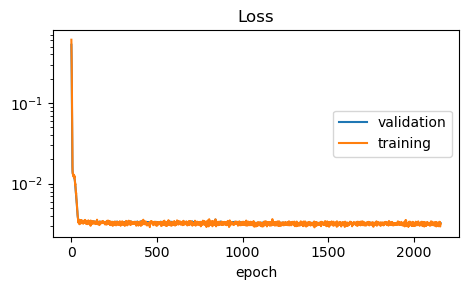

Epoch 2202, Loss: 3.459e-03/5.0e-03, LR: 1.3e-05, Last_save: 1702: : 2202it [00:55, 39.68it/s]


Training finished.


In [79]:
# Training loop
TIMESTEP = 3
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP, loss_goal=1e-5)

/tmp/ipykernel_2311666/782184491.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 2.385e-03 --> 2.751e-03
Difference: -3.660e-04
Total Trainable Parameters: 2,404


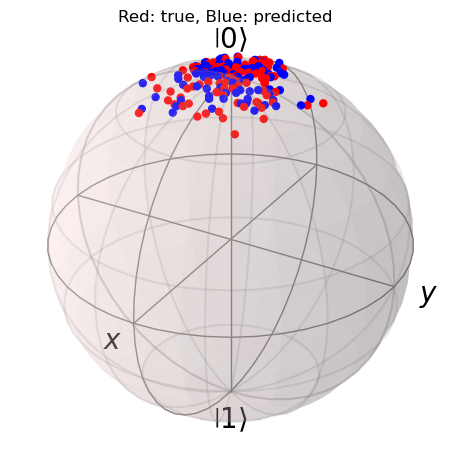

In [80]:
show_results(model, TIMESTEP)

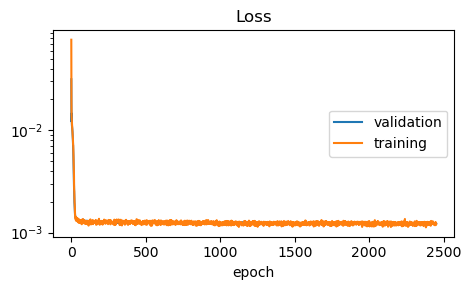

Epoch 2482, Loss: 1.071e-03/5.0e-03, LR: 2.5e-05, Last_save: 1982: : 2482it [00:56, 43.66it/s]

Training finished.


In [81]:
# Training loop
TIMESTEP = 2
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP, loss_goal=1e-5)

/tmp/ipykernel_2311666/782184491.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 9.329e-04 --> 4.104e-04
Difference: 5.225e-04
Total Trainable Parameters: 2,404


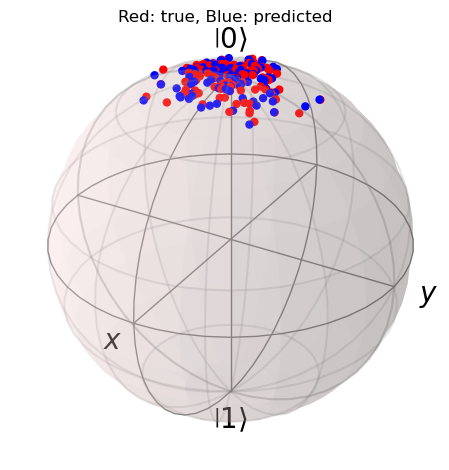

In [82]:
show_results(model, TIMESTEP)

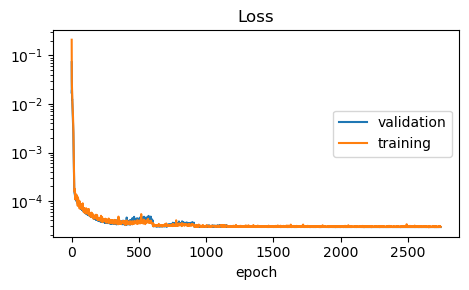

Epoch 2791, Loss: 2.659e-05/5.0e-03, LR: 1.6e-06, Last_save: 2291: : 2791it [00:59, 46.60it/s]

Training finished.


In [83]:
# Training loop
TIMESTEP = 1
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)
train(model, TIMESTEP, loss_goal=1e-5)

/tmp/ipykernel_2311666/782184491.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


Wass distance: 3.135e-05 --> 1.851e-06
Difference: 2.950e-05
Total Trainable Parameters: 2,404


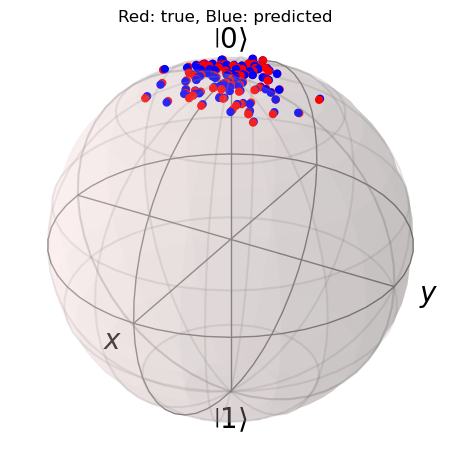

In [84]:
show_results(model, TIMESTEP)